In [21]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import time 
import xgboost as xgb
import shap


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc





Start off by initializing the program and all the models to be used


In [23]:

pf = pd.read_csv('email.csv',
                 encoding="utf-8",
                 encoding_errors="replace")


In [24]:
print(pf.columns.tolist())
pf.dtypes

['id', 'date', 'user', 'pc', 'to', 'cc', 'bcc', 'from', 'size', 'attachments', 'content']


id               str
date             str
user             str
pc               str
to               str
cc               str
bcc              str
from             str
size           int64
attachments    int64
content          str
dtype: object

In [25]:
null_report = (
    pf.isnull().sum())




In [26]:
# this is responsible for stripping off the timezone noise to be caused later on in the code structure
pf["date"] = pf["date"].astype(str).replace(
    r"\s?(EST|EDT|UTC|GMT).*$", "", regex=True
).str.strip()
# this is to parse with fallback for mixed formats
pf['datetime'] = pd.to_datetime(pf['date'], errors="coerce")
# this checks the columns that have failed to parse
failed_parsing = pf[pd.to_datetime(pf['date'], errors='coerce').isna()]
print(f"Number of rows with failed date parsing: {len(failed_parsing)}")



Number of rows with failed date parsing: 0


In [27]:
# Cleaning the data by stripping whitespace and standardizing case for 'user' and 'from' columns
# This is important for accurate feature extraction and to avoid mismatches due to case sensitivity or leading/trailing spaces.
pf["user"] = pf["user"].str.strip().str.upper()
pf["from"] = pf["from"].str.strip().str.lower()



pf = pf.dropna(subset=["user"])


pf["user_prefix"] = pf["user"].str[:3].str.lower()
pf["from_prefix"] = pf["from"].str.split(".").str[0].str[:3].fillna("")
pf["sender_mismatch"] = (pf["user_prefix"] != pf["from_prefix"]).astype(int)


In [28]:
# size is in bytes — cast to numeric, coerce bad strings
from regex import P


pf["size"] = pd.to_numeric(pf["size"], errors="coerce")

# Negative sizes are data errors — zero them out
pf["size"] = pf["size"].clip(lower=0)

# Fill null sizes with median (not mean — skewed distribution)
median_size = pf["size"].median()
pf["size"] = pf["size"].fillna(median_size)

# Convert bytes → KB for readability
pf["size_kb"] = (pf["size"] / 1024).round(2)

# Attachments: null means 0, not unknown
pf["attachments"] = pd.to_numeric(pf["attachments"], errors="coerce").fillna(0).astype(int)
pf["has_attachment"] = (pf["attachments"] > 0).astype(int)

# Outlier flag: emails > 99.5th percentile in size are suspicious
size_cap = pf["size_kb"].quantile(0.995)
pf["is_large_email"] = (pf["size_kb"] > size_cap).astype(int)
print(f"Large email threshold: {size_cap:.1f} KB")

pf["exfil_signal"] = (
    (pf["is_large_email"] == 1) &
    (pf["has_attachment"] == 1) &
    (pf["sender_mismatch"] == 1)
).astype(int)
print(f"Exfiltration signal rows: {pf['exfil_signal'].sum()}")

Large email threshold: 64.1 KB
Exfiltration signal rows: 987


In [ ]:
# Null content = empty email body, not missing data
pf["content"] = pf["content"].fillna("").astype(str)

# Remove encoding artifacts common in CERT dataset
pf["content_clean"] = (
    pf["content"]
    .str.replace(r"[^\x00-\x7F]", " ", regex=True) 
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.lower()
)

# Structural features
pf["content_length"]  = pf["content_clean"].str.len()
pf["word_count"]      = pf["content_clean"].str.split().str.len().fillna(0)
pf["is_empty_body"]  = (pf["content_length"] == 0).astype(int)

# Threat lexicon — grouped by scenario type
EXFIL_KEYWORDS = [
    "confidential", "proprietary", "trade secret",
    "do not share", "restricted", "internal only"
]
RESIGNATION_KEYWORDS = [
    "two weeks", "last day", "resignation",
    "new job", "leaving", "offer letter", "job offer"
]
SABOTAGE_KEYWORDS = [
    "delete", "destroy", "wipe", "corrupt",
    "damage", "shut down", "disable"
]
def keyword_flag(text_series, keywords):
    pattern = "|".join(keywords)
    return text_series.str.contains(pattern, regex=True, na=False).astype(int)

pf["flag_exfil_keywords"]      = keyword_flag(pf["content_clean"], EXFIL_KEYWORDS)
pf["flag_resignation_keywords"] = keyword_flag(pf["content_clean"], RESIGNATION_KEYWORDS)
pf["flag_sabotage_keywords"]    = keyword_flag(pf["content_clean"], SABOTAGE_KEYWORDS)

# Composite content threat score (0-3)
pf["content_threat_score"] = (
    pf["flag_exfil_keywords"] +
    pf["flag_resignation_keywords"] +
    pf["flag_sabotage_keywords"])

In [ ]:
# Checking for duplicates 
before = len(pf)
pf = pf.drop_duplicates()
print(f"Dropped {before - len(pf)} exact duplicates")

# Drop near-duplicates: same user, datetime, recipient, size
# (CERT occasionally logs the same send event twice)
pf = pf.drop_duplicates(subset=["user", "datetime", "to", "size"], keep="first")
print(f"Rows after near-dedup: {len(pf):,}")

Dropped 0 exact duplicates
Rows after near-dedup: 1,048,575


In [ ]:
pf["is_insider"] = pf["user"].str.strip().isin(['insider1', 'insider2', 'insider3']).astype(int)
print(f"Insider emails: {pf['is_insider'].sum()} out of {len(pf)} total")

Insider emails: 0 out of 1048575 total


In [ ]:
# Training data for modeling

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# 1. Target Labeling
pf["is_insider"] = pf["user"].isin(['insider1', 'insider2', 'insider3']).astype(int)

# 2. Feature Engineering (Ensuring they are numeric)
# Convert cc/bcc to counts so the model can read them
pf['cc_count'] = pf['cc'].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)
pf['bcc_count'] = pf['bcc'].fillna('').apply(lambda x: len(str(x).split(',')) if x != '' else 0)

CANDIDATE_FEATURES = [ 
    'cc_count', 'bcc_count', 'size', 'attachments', 'sender_mismatch',
    'has_attachment', 'is_large_email', 'content_length', 'word_count',
    'is_empty_body', 'content_threat_score'
]

X = pf[CANDIDATE_FEATURES].fillna(0)
y = pf['is_insider']

# 3. Defensive Check: Ensure we have enough data to split
if y.nunique() < 2:
    print(f"CRITICAL ERROR: Only {y.nunique()} class found in 'is_insider'.")
    print("Check if the usernames 'insider1', 'insider2', etc., actually exist in pf['user'].")
else:
    # Everything dependent on X_train MUST stay inside this 'else' block
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # 4. Initialize and Fit
    gb = GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42, max_features="sqrt"
    )

    print("Training the model...")
    gb.fit(X_train, y_train)

    # 5. Predict and Evaluate
    y_prob = gb.predict_proba(X_test)[:, 1]
    y_pred = gb.predict(X_test)

    print("\n--- Model Performance Report ---")
    print(classification_report(y_test, y_pred))

CRITICAL ERROR: Only 1 class found in 'is_insider'.
Check if the usernames 'insider1', 'insider2', etc., actually exist in pf['user'].


In [ ]:
# Cross validating with GridSearchCV for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01],
    'max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid, 
    cv=5, scoring='f1'
)
print("Starting Grid Search for hyperparameter tuning...")
grid_search.fit(X_train, y_train)
print(f"Best parameters found: {grid_search.best_params_}")
best_gb = grid_search.best_estimator_
y_pred_best = best_gb.predict(X_test)
print("\n--- Best Model Performance Report ---")
print(classification_report(y_test, y_pred_best))


In [ ]:
# After cleaning, we have a rich set of engineered features ready for modeling. Next, we'll select candidate features and evaluate their predictive power using mutual information scores.
CANDIDATE_FEATURES = ['size', 'attachments',
                      'sender_mismatch','has_attachment',  
                      'is_large_email', 'exfil_signal', 'content_length', 'word_count',
                      'is_empty_body', 'flag_exfil_keywords', 'flag_resignation_keywords', 
                      'flag_sabotage_keywords', 'content_threat_score',]
X = pf[CANDIDATE_FEATURES].fillna(0)
y = pf['is_insider']
mi_scores = mutual_info_classif(X, y, random_state=42)
feature_mi = pd.Series(mi_scores, index=CANDIDATE_FEATURES).sort_values(ascending=False)
print(feature_mi)

sender_mismatch              0.178250
has_attachment               0.031296
word_count                   0.007300
attachments                  0.003595
content_threat_score         0.003272
flag_sabotage_keywords       0.002823
content_length               0.000955
flag_resignation_keywords    0.000695
is_large_email               0.000074
flag_exfil_keywords          0.000074
exfil_signal                 0.000010
size                         0.000004
is_empty_body                0.000000
dtype: float64


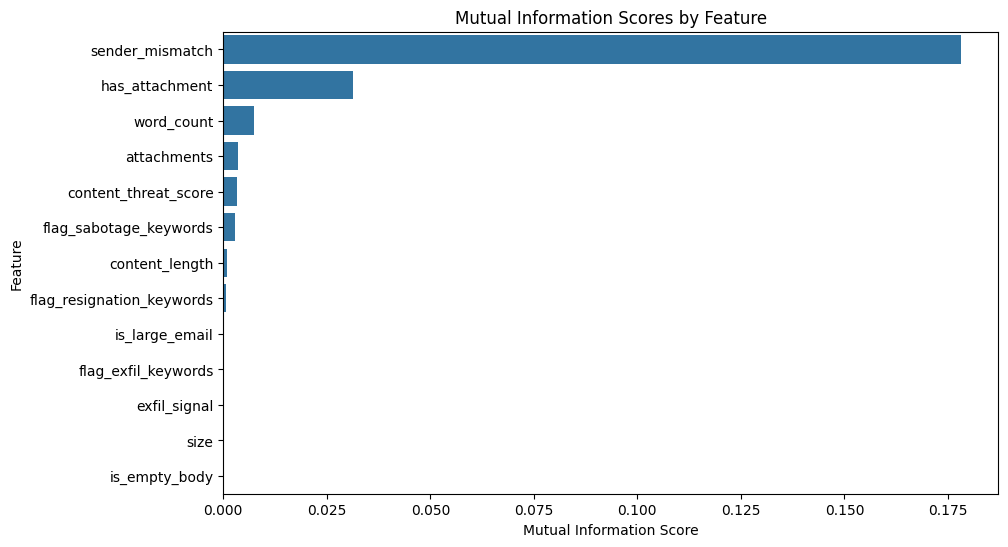

In [ ]:
# Visual representation of feature importance: using a bar plot to show mutual information scores for each feature, which helps us understand which features are most predictive of insider status.
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_mi.values, y=feature_mi.index)
plt.title("Mutual Information Scores by Feature")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.show()


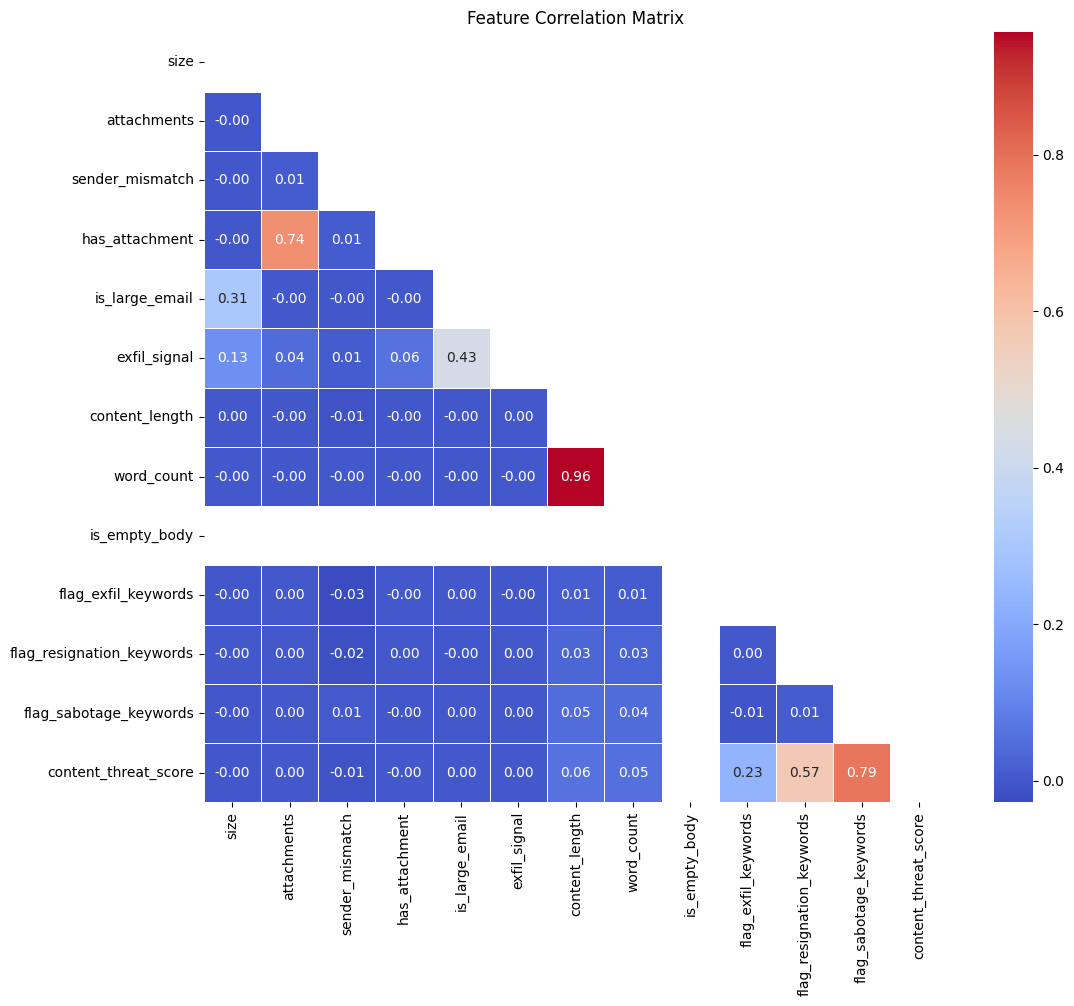

In [ ]:
# Visual representation of feature importance: using a heatmap to show the correlation matrix of features, which can reveal clusters of related features and potential multicollinearity issues.
plt.figure(figsize=(12, 10))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True, linewidths=0.5, mask=np.triu(X.corr()))
plt.title("Feature Correlation Matrix")
plt.show()
